# Brain Stroke Detection from CT Images using VGG16

## Project Overview
This project aims to detect the presence of strokes in Brain CT images using Deep Learning.
We utilize **Transfer Learning** with the **VGG16** architecture, pre-trained on ImageNet weights. The model is fine-tuned on a dataset of DICOM images to classify them into two categories:
- **Stroke (İnme Var)**
- **No Stroke (İnme Yok)**

## Methodology
1.  **Data Preprocessing:** DICOM images are processed using "Brain Windowing" (Center=40, Width=80) to highlight brain tissue.
2.  **Model Architecture:** VGG16 base (frozen) + Custom Classification Head.
3.  **Training:** Initial training followed by Fine-Tuning of the last convolutional block.
4.  **Evaluation:** Metrics include Accuracy, Loss, ROC Curve, and Confusion Matrix.

## Data Path Configuration
**Important:** The dataset paths in this notebook are configured for a specific Google Drive structure.
- **Current Path:** `/content/drive/MyDrive/teknofest_training_dicom`
- **Action Required:** If you are forking or running this notebook, please update the `SOURCE_BASE_DIR` variable in the code to point to your own dataset location.

In [1]:
!pip install -q pydicom python-gdcm pylibjpeg pylibjpeg-libjpeg
!pip install -q tensorflow numpy pandas matplotlib

import os
import cv2
import numpy as np
import pandas as pd
import pydicom as dicom
import gdcm
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
from google.colab import drive
import os
import shutil

drive.mount('/content/drive')

# Source directories
SOURCE_BASE_DIR = "/content/drive/MyDrive/teknofest_training_dicom"
SOURCE_INME_YOK = os.path.join(SOURCE_BASE_DIR, "inme_yok_dicom")
SOURCE_INME_VAR = os.path.join(SOURCE_BASE_DIR, "inme_var_dicom")

# Target directory (Colab local disk)
extract_path = "/content/dataset"
TARGET_INME_YOK = os.path.join(extract_path, "inme_yok_dicom")
TARGET_INME_VAR = os.path.join(extract_path, "inme_var_dicom")


if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Copy data from Drive to local disk to improve training speed
if not os.path.exists(TARGET_INME_YOK) or not os.path.exists(TARGET_INME_VAR):

    if os.path.exists(SOURCE_INME_YOK):
        shutil.copytree(SOURCE_INME_YOK, TARGET_INME_YOK, dirs_exist_ok=True)
    else:
        print(f"ERROR: Source folder not found: {SOURCE_INME_YOK}")

    if os.path.exists(SOURCE_INME_VAR):
        shutil.copytree(SOURCE_INME_VAR, TARGET_INME_VAR, dirs_exist_ok=True)
    else:
        print(f"ERROR: Source folder not found: {SOURCE_INME_VAR}")

    print("Data copy complete.")
else:
    print("Data already exists on local disk.")

# Update data paths to use local disk
DATA_DIR = extract_path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already exists on local disk.


In [3]:
import os

# Set BASE_DIR to DATA_DIR defined in the previous cell.
# DATA_DIR points to the local Colab disk directory "/content/dataset".
# If this cell is run independently and DATA_DIR is not defined, use the default path as a fallback.
if 'DATA_DIR' in globals():
    BASE_DIR = DATA_DIR
else:
    BASE_DIR = "/content/drive/MyDrive/teknofest_training_dicom" # Fallback

print(f"Data path set to: {BASE_DIR}")

# Define directory paths
INME_YOK = os.path.join(BASE_DIR, "inme_yok_dicom")
INME_VAR = os.path.join(BASE_DIR, "inme_var_dicom")

all_data = []

# No Stroke (Label: 0)
print(f"Scanning: {INME_YOK}")
if os.path.exists(INME_YOK):
    for root, dirs, files in os.walk(INME_YOK):
        for file in files:
            if file.lower().endswith(".dcm"):
                full_path = os.path.join(root, file)
                all_data.append((full_path, 0))
else:
    print(f"ERROR: Folder not found: {INME_YOK}")

# Stroke Present (Label: 1)
print(f"Scanning: {INME_VAR}")
if os.path.exists(INME_VAR):
    for root, dirs, files in os.walk(INME_VAR):
        for file in files:
            if file.lower().endswith(".dcm"):
                full_path = os.path.join(root, file)
                all_data.append((full_path, 1))
else:
    print(f"ERROR: Folder not found: {INME_VAR}")

print("-" * 30)
print(f"Total images found: {len(all_data)}")

if len(all_data) > 0:
    print(f"Sample data path: {all_data[0]}")
else:
    print("ERROR: No files found.")

Data path set to: /content/dataset
Scanning: /content/dataset/inme_yok_dicom
Scanning: /content/dataset/inme_var_dicom
------------------------------
Total images found: 6650
Sample data path: ('/content/dataset/inme_yok_dicom/11097.dcm', 0)


In [4]:
# Calculate class distribution
inme_yok_count = sum(1 for _, label in all_data if label == 0)
inme_var_count = sum(1 for _, label in all_data if label == 1)

print(f"'No Stroke' data count: {inme_yok_count}")
print(f"'Stroke' data count: {inme_var_count}")

'No Stroke' data count: 4427
'Stroke' data count: 2223


In [5]:
from sklearn.model_selection import train_test_split

# Split data: 80% Training, 20% Validation
# train_test_split shuffles the data by default.
# random_state=42 ensures reproducibility. (same split every time)
train_data, val_data = train_test_split(all_data, test_size=0.2, random_state=42)

print(f"Training data count: {len(train_data)}")
print(f"Validation data count: {len(val_data)}")

Training data count: 5320
Validation data count: 1330


In [6]:
def preprocess_dicom(path, target_size=(224, 224)):
    """
    Reads a DICOM file, applies Brain Windowing, and prepares it for VGG16.
    Brain Window: Center (WL)=40, Width (WW)=80
    """
    try:
        dcm = dicom.dcmread(path)
        img = dcm.pixel_array.astype(float)

        # Apply Rescale Slope and Intercept if available
        slope = getattr(dcm, 'RescaleSlope', 1)
        intercept = getattr(dcm, 'RescaleIntercept', 0)
        img = (img * slope) + intercept

        # Apply Brain Windowing
        center = 40
        width = 80
        min_value = center - (width / 2)
        max_value = center + (width / 2)

        img = np.clip(img, min_value, max_value)

        # Normalize to 0-1 range
        img = (img - min_value) / (max_value - min_value)

        # Resize image
        img = cv2.resize(img, target_size)

        # Stack to 3 channels (Grayscale -> RGB)
        img = np.stack((img,)*3, axis=-1)

        return img

    except Exception as e:
        print(f"Error processing file: {path}, Error: {e}")
        return np.zeros((target_size[0], target_size[1], 3))

In [7]:
class DataGenerator(Sequence):
    """
    Custom Keras DataGenerator to load and preprocess DICOM images in batches.
    """
    def __init__(self, data_list, batch_size=32, dim=(224, 224), shuffle=True):
        self.dim = dim
        self.batch_size = batch_size
        self.data_list = data_list
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        # Denotes the number of batches per epoch
        return int(np.floor(len(self.data_list) / self.batch_size))

    def __getitem__(self, index):
        # Generate one batch of data
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_list = [self.data_list[k] for k in indexes]

        X, y = self.__data_generation(batch_list)
        return X, y

    def on_epoch_end(self):
        # Updates indexes after each epoch
        self.indexes = np.arange(len(self.data_list))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, batch_list):
        # Generates data containing batch_size samples
        X = np.empty((self.batch_size, *self.dim, 3))
        y = np.empty((self.batch_size), dtype=int)

        for i, (path, label) in enumerate(batch_list):
            img = preprocess_dicom(path, target_size=self.dim)
            X[i,] = img
            y[i] = label

        return X, y

# Create data generators
# Batch size is set to 16 to optimize VRAM usage (can be adjusted to 32 if hardware allows)
train_gen = DataGenerator(train_data, batch_size=16, dim=(224, 224))
val_gen = DataGenerator(val_data, batch_size=16, dim=(224, 224), shuffle=False)

In [8]:
def build_model():
    # Initialize VGG16 model with pre-trained ImageNet weights
    # include_top=False excludes the original fully connected layers
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze the base model layers to prevent weight updates during initial training
    base_model.trainable = False

    # Add custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Reduces parameters and risk of overfitting compared to Flatten
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)  # Regularization to prevent overfitting
    predictions = Dense(1, activation='sigmoid')(x)  # Binary classification output

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
# Compile the model
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
callbacks = [
    # Save the best model based on validation loss
    ModelCheckpoint('best_stroke_model.keras', save_best_only=True, monitor='val_loss', mode='min'),

    # Stop training if validation loss does not improve for 5 epochs
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),

    # Reduce learning rate if validation loss plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
]

In [10]:
# Define class weights to address dataset imbalance
# Class 1 (Stroke) is weighted higher to penalize false negatives more heavily
class_weights = {
    0: 1.0,  # No Stroke
    1: 2.0   # Stroke Present
}

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 96s 269ms/step - accuracy: 0.5132 - loss: 0.9718 - val_accuracy: 0.7839 - val_loss: 0.5880 - learning_rate: 1.0000e-04
Epoch 2/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 265ms/step - accuracy: 0.6468 - loss: 0.8362 - val_accuracy: 0.7681 - val_loss: 0.5509 - learning_rate: 1.0000e-04
Epoch 3/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 265ms/step - accuracy: 0.7247 - loss: 0.7514 - val_accuracy: 0.7816 - val_loss: 0.5101 - learning_rate: 1.0000e-04
Epoch 4/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 266ms/step - accuracy: 0.7438 - loss: 0.7105 - val_accuracy: 0.7892 - val_loss: 0.4921 - learning_rate: 1.0000e-04
Epoch 5/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 265ms/step - accuracy: 0.7578 - loss: 0.6846 - val_accuracy: 0.7530 - val_loss: 0.5138 - learning_rate: 1.0000e-04
Epoch 6/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 265ms/step - accuracy: 0.7552 - loss: 0.6749 - val_accuracy: 0.8012 - val_loss: 0.4544 - learning_rate: 1.0000e-04
Epoch 7/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 89s 26

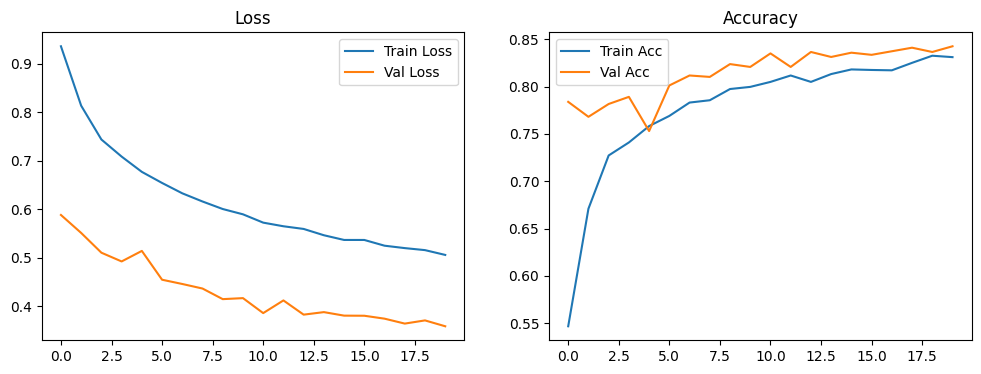

In [11]:
# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

# Visualize training results
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.show()

Epoch 1/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.8466 - loss: 0.4803 - val_accuracy: 0.8818 - val_loss: 0.2923 - learning_rate: 1.0000e-05
Epoch 2/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 266ms/step - accuracy: 0.9096 - loss: 0.3127 - val_accuracy: 0.8998 - val_loss: 0.2270 - learning_rate: 1.0000e-05
Epoch 3/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 266ms/step - accuracy: 0.9338 - loss: 0.2554 - val_accuracy: 0.9262 - val_loss: 0.1822 - learning_rate: 1.0000e-05
Epoch 4/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 89s 267ms/step - accuracy: 0.9475 - loss: 0.1996 - val_accuracy: 0.9352 - val_loss: 0.1595 - learning_rate: 1.0000e-05
Epoch 5/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 266ms/step - accuracy: 0.9488 - loss: 0.1910 - val_accuracy: 0.9315 - val_loss: 0.1777 - learning_rate: 1.0000e-05
Epoch 6/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 265ms/step - accuracy: 0.9806 - loss: 0.1000 - val_accuracy: 0.9405 - val_loss: 0.1434 - learning_rate: 1.0000e-05
Epoch 7/10
332/332 ━━━━━━━━━━━━━━━━━━━━ 88s 26

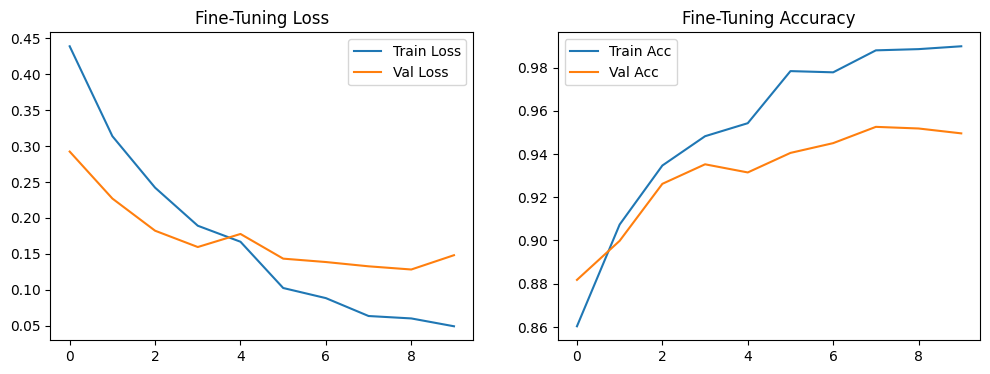

In [12]:
# Unfreeze specific layers for fine-tuning (Block 5 and above)
set_trainable = False

# Iterate through the model layers
for layer in model.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True

    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile the model with a lower learning rate (1e-5)
# A lower learning rate is crucial for fine-tuning to prevent destroying learned features
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Continue training (Fine-tuning phase)
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights
)

# Visualize fine-tuning results
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Fine-Tuning Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history_fine.history['accuracy'], label='Train Acc')
plt.plot(history_fine.history['val_accuracy'], label='Val Acc')
plt.title('Fine-Tuning Accuracy')
plt.legend()

plt.show()

In [14]:
import random
import numpy as np

# Select a random sample from the validation set
random_sample = random.choice(val_data)
random_path, true_label = random_sample

print(f"Selected File: {random_path}")
print(f"True Label: {'Stroke' if true_label == 1 else 'No Stroke'}")

# Process the image (Preprocess only, no visualization)
processed_image = preprocess_dicom(random_path)

# Expand dimensions to match model input shape (Batch Size, Height, Width, Channels)
input_image = np.expand_dims(processed_image, axis=0)

# Make a prediction
prediction_probability = model.predict(input_image)[0][0]
predicted_label = 1 if prediction_probability > 0.5 else 0

# Display prediction results (Text only)
print("-" * 30)
print(f"Prediction Probability: {prediction_probability:.4f}")
print(f"Predicted Label: {'Stroke' if predicted_label == 1 else 'No Stroke'}")
print("-" * 30)

Selected File: /content/dataset/inme_yok_dicom/12991.dcm
True Label: No Stroke
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
------------------------------
Prediction Probability: 0.0036
Predicted Label: No Stroke
------------------------------


In [15]:
from tensorflow.keras.models import load_model

# Load the best saved model
print("Loading the best performing model...")
final_model = load_model('best_stroke_model.keras')

# Evaluate the final model on validation data
val_loss, val_acc = final_model.evaluate(val_gen)

print("-" * 30)
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"Final Validation Loss: {val_loss:.4f}")
print("-" * 30)

Loading the best performing model...
83/83 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.9500 - loss: 0.1295
------------------------------
Final Validation Accuracy: 95.18%
Final Validation Loss: 0.1282
------------------------------


Generating evaluation plots...


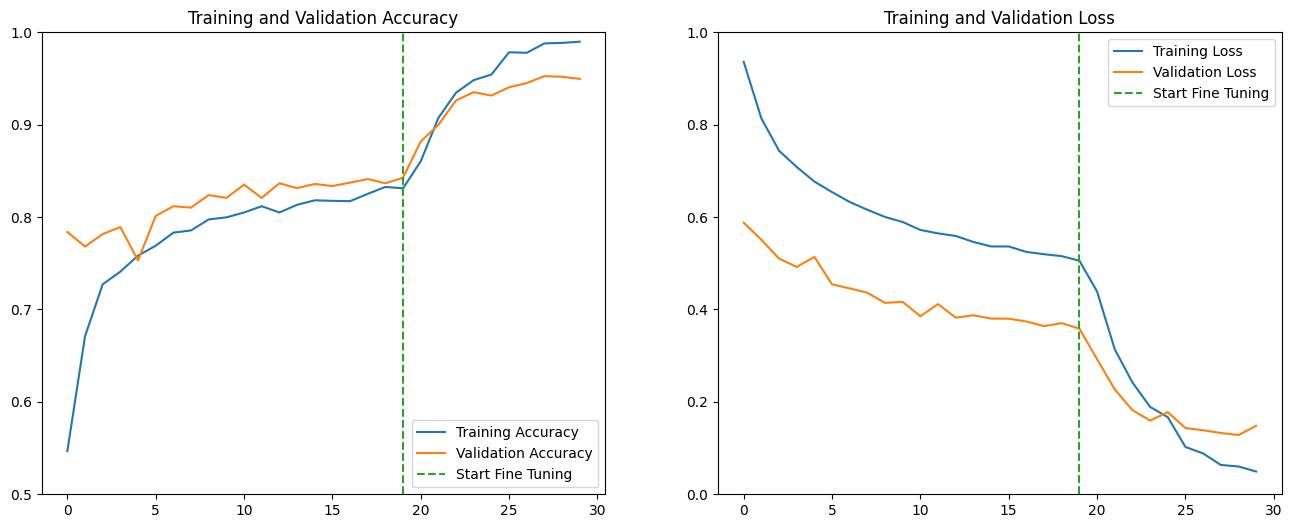

Generating predictions on validation set...
83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 210ms/step


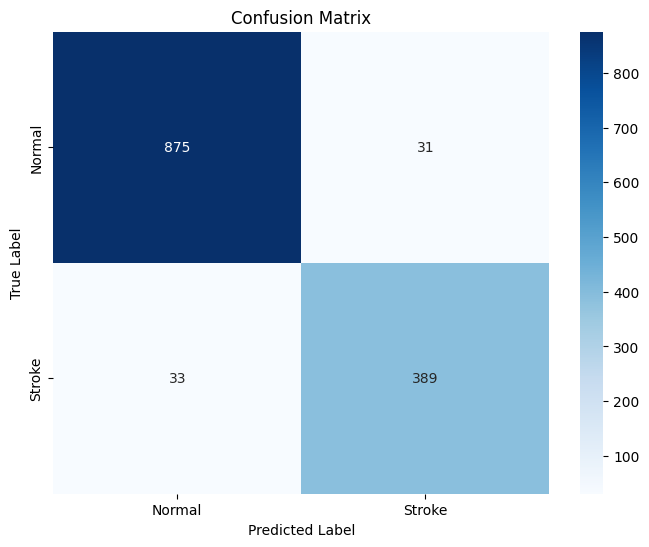

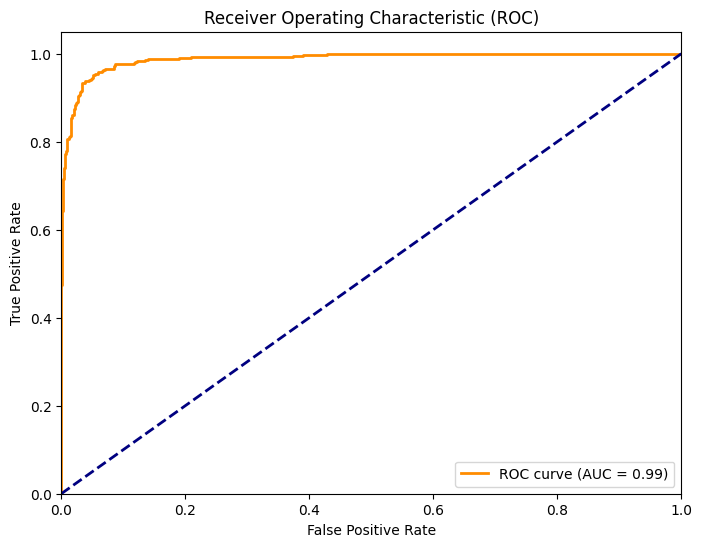


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.96       906
      Stroke       0.93      0.92      0.92       422

    accuracy                           0.95      1328
   macro avg       0.94      0.94      0.94      1328
weighted avg       0.95      0.95      0.95      1328

Plots saved to directory: results


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import numpy as np
import os

# Create a directory to save the results
save_dir = "results"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

print("Generating evaluation plots...")

# --- 1. COMBINE TRAINING HISTORY (INITIAL + FINE-TUNING) ---
try:
    # Concatenate history from initial training and fine-tuning
    acc = history.history['accuracy'] + history_fine.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
    loss = history.history['loss'] + history_fine.history['loss']
    val_loss = history.history['val_loss'] + history_fine.history['val_loss']
    initial_epochs = len(history.history['accuracy'])
    has_full_history = True
except NameError:
    # Fallback if only fine-tuning history is available
    acc = history_fine.history['accuracy']
    val_acc = history_fine.history['val_accuracy']
    loss = history_fine.history['loss']
    val_loss = history_fine.history['val_loss']
    initial_epochs = 0
    has_full_history = False

plt.figure(figsize=(16, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.5, 1])
if has_full_history:
    plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning', linestyle='--')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
if has_full_history:
    plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning', linestyle='--')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig(f"{save_dir}/training_performance.png")
plt.show()


# --- 2. GENERATE PREDICTIONS ---
print("Generating predictions on validation set...")

# Predict using the validation generator
# Note: Ensure val_gen.shuffle is False to match predictions with true labels
predictions = model.predict(val_gen)
y_pred = (predictions > 0.5).astype(int)

# Extract true labels from the validation data list
y_true = np.array([label for path, label in val_data])

# Handle potential batch size mismatch (drop last partial batch if necessary)
if len(y_true) != len(y_pred):
    y_true = y_true[:len(y_pred)]


# --- 3. CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Stroke'], yticklabels=['Normal', 'Stroke'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.savefig(f"{save_dir}/confusion_matrix.png")
plt.show()

print()

# --- 4. ROC CURVE & AUC ---
fpr, tpr, thresholds = roc_curve(y_true, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig(f"{save_dir}/roc_curve.png")
plt.show()

# Print Classification Report
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Stroke']))
print(f"Plots saved to directory: {save_dir}")